In [1]:
%load_ext autoreload
%autoreload 2
import tqdm, tqdm.notebook

tqdm.tqdm = tqdm.notebook.tqdm  # notebook-friendly progress bars
from pathlib import Path
import numpy as np

from hloc import (
    extract_features,
    match_features,
    reconstruction,
    visualization,
    pairs_from_exhaustive,
)
from hloc.visualization import plot_images, read_image
from hloc.utils import viz_3d

In [2]:
images = Path("datasets/A")
outputs = Path("outputs/demo/")
!rm -rf $outputs
sfm_pairs = outputs / "pairs-sfm.txt"
loc_pairs = outputs / "pairs-loc.txt"
sfm_dir = outputs / "sfm"
features = outputs / "features.h5"
matches = outputs / "matches.h5"

feature_conf = extract_features.confs["superpoint_inloc"]
matcher_conf = match_features.confs["superpoint+lightglue"]

'rm' ���O�����Υ~���R�O�B�i���檺�{���Χ妸�ɡC


3 mapping images


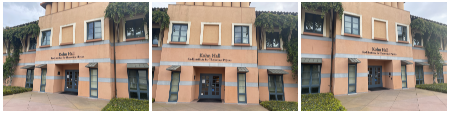

In [3]:
references = [p.relative_to(images).as_posix() for p in (images).iterdir()]
print(len(references), "mapping images")
plot_images([read_image(images / r) for r in references], dpi=25)

In [4]:
extract_features.main(
    feature_conf, images, image_list=references, feature_path=features
)
pairs_from_exhaustive.main(sfm_pairs, image_list=references)
match_features.main(matcher_conf, sfm_pairs, features=features, matches=matches);

[2025/04/25 15:27:54 hloc INFO] Extracting local features with configuration:
{'model': {'max_keypoints': 4096, 'name': 'superpoint', 'nms_radius': 4},
 'output': 'feats-superpoint-n4096-r1600',
 'preprocessing': {'grayscale': True, 'resize_max': 1600}}
[2025/04/25 15:27:54 hloc INFO] Skipping the extraction.
[2025/04/25 15:27:54 hloc INFO] Found 3 pairs.
[2025/04/25 15:27:54 hloc INFO] Matching local features with configuration:
{'model': {'features': 'superpoint', 'name': 'lightglue'},
 'output': 'matches-superpoint-lightglue'}
[2025/04/25 15:27:54 hloc INFO] Skipping the matching.


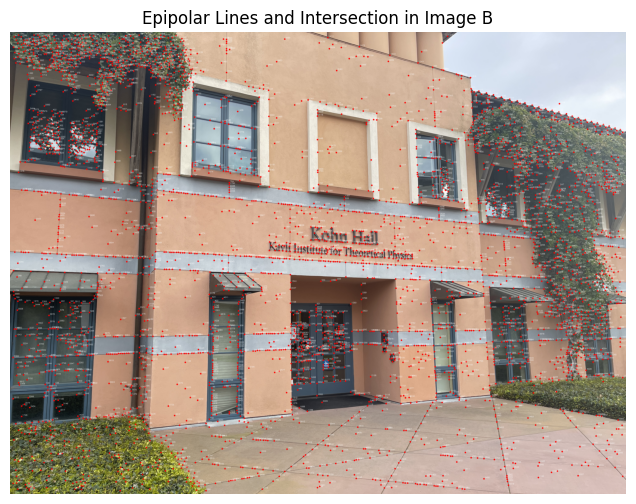

In [5]:
import h5py
import numpy as np
import cv2
import matplotlib.pyplot as plt

img1_name = 'IMG_1223.JPG'
img2_name = 'IMG_1224.JPG'
img3_name = 'IMG_1226.JPG'

# Load keypoints from features.h5
with h5py.File('outputs/demo/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load the actual image
img1 = cv2.imread('G:\Machine Learning\CV\IMG_1223.jpg')
img2 = cv2.imread('G:\Machine Learning\CV\IMG_1224.jpg')
img3 = cv2.imread('G:\Machine Learning\CV\IMG_1226.jpg')

# Draw keypoints
for idx, (x, y) in enumerate(kpts3):
    x, y = int(x), int(y)
    cv2.circle(img3, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img3, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()

In [6]:
import h5py
import numpy as np
import cv2

img1_name = 'IMG_1223.JPG'
img2_name = 'IMG_1224.JPG'
img3_name = 'IMG_1226.JPG'

# Load keypoints from features.h5
with h5py.File('outputs/demo/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load LightGlue matches0 from matches.h5
with h5py.File('outputs/demo/matches.h5', 'r') as f:
    matches0 = f[img1_name][img2_name]['matches0'][:]  # shape (N1,)
    matches1 = f[img2_name][img3_name]['matches0'][:]  # shape (N1,)
    matches2 = f[img1_name][img3_name]['matches0'][:]  # shape (N1,)

# Valid matches are those >= 0
valid_ab = matches0 > -1
pts_A = kpts1[valid_ab]
pts_B = kpts2[matches0[valid_ab]]

# B-C matching
valid_bc = matches1 > -1
pts_B2 = kpts2[valid_bc]
pts_C = kpts3[matches1[valid_bc]]

# A-C direct matching
valid_ac = matches2 > -1
pts_A2 = kpts1[valid_ac]
pts_C2 = kpts3[matches2[valid_ac]]
pts_A = np.array(pts_A, dtype=np.float32)
pts_B = np.array(pts_B, dtype=np.float32)
pts_C = np.array(pts_C, dtype=np.float32)
pts_A2 = np.array(pts_A2, dtype=np.float32)
pts_B2 = np.array(pts_B2, dtype=np.float32)
pts_C2 = np.array(pts_C2, dtype=np.float32)

from Homography import Homography

# Compute homographies
HMG = Homography()
H1, inlier1 = HMG.compute_homography_ransac(pts_A, pts_B)   # A to B
H2, inlier2 = HMG.compute_homography_ransac(pts_B2, pts_C)  # B to C
H3, inlier3 = HMG.compute_homography_ransac(pts_A2, pts_C2) # A to C
pts_A, pts_B = pts_A[inlier1], pts_B[inlier1]
pts_B2, pts_C = pts_B2[inlier2], pts_C[inlier2]
pts_A2, pts_C2 = pts_A2[inlier3], pts_C2[inlier3]
print("Estimated Homography Matrix 1:\n", H1)
print("Estimated Homography Matrix 2:\n", H2)
print("Estimated Homography Matrix 3:\n", H3)
HA = np.matmul(H1,np.append(pts_A[10],1))
HB = np.matmul(H2,np.append(pts_B2[10],1))
HC = np.matmul(H3,np.append(pts_A2[10],1))
CA = [HA[0]/HA[2],HA[1]/HA[2]]
CB = [HB[0]/HB[2],HB[1]/HB[2]]
CC = [HC[0]/HC[2],HC[1]/HC[2]]
print("Validation A-B: Point in A:",pts_A[10],"Point in B:",pts_B[10],"Reconstructed Point:",CA)
print("Validation B-C: Point in B:",pts_B2[10],"Point in C:",pts_C[10],"Reconstructed Point:",CB)
print("Validation A-C: Point in A:",pts_A2[10],"Point in C:",pts_C2[10],"Reconstructed Point:",CC)

Estimated Homography Matrix 1:
 [[ 2.28104423e+00 -5.58876993e-02 -1.66142108e+03]
 [ 5.43112950e-01  1.58006649e+00 -1.13655309e+03]
 [ 2.53029083e-04 -2.27298789e-05  1.00000000e+00]]
Estimated Homography Matrix 2:
 [[ 1.29599559e+00  2.10239670e-01  4.76559097e+02]
 [ 2.22483736e-01  1.25623652e+00 -4.91990095e+02]
 [ 1.29932770e-04  6.53722124e-05  1.00000000e+00]]
Estimated Homography Matrix 3:
 [[ 4.73345223e+00  3.41749079e-01 -2.93672636e+03]
 [ 1.61794701e+00  2.86191230e+00 -3.42760225e+03]
 [ 8.91899599e-04  7.41637846e-05  1.00000000e+00]]
Validation A-B: Point in A: [1606. 1427.] Point in B: [1397. 1447.] Reconstructed Point: [1399.041702580604, 1448.7218360481868]
Validation B-C: Point in B: [2450. 1147.] Point in C: [2790. 1072.] Reconstructed Point: [2793.9748106469447, 1072.2600249938557]
Validation A-C: Point in A: [2017. 1510.] Point in C: [2450. 1427.] Reconstructed Point: [2448.2353915143112, 1428.1544364394904]


Estimated Fundamental Matrix F1:
 [[-5.52670528e-08 -1.19905908e-06  2.17906217e-03]
 [ 1.40865734e-06 -1.57363692e-08 -2.31578209e-03]
 [-2.48535199e-03  1.80057725e-03  1.00000000e+00]]
Estimated Fundamental Matrix F2:
 [[ 4.21554335e-09  6.22178870e-07 -1.18239768e-03]
 [-5.48035057e-07 -4.84686953e-08  8.49148771e-04]
 [ 9.13782291e-04 -1.19670411e-03  1.00000000e+00]]
Estimated Fundamental Matrix F3:
 [[ 1.21348340e-07  7.50200909e-07 -1.28258861e-03]
 [-7.45482590e-07 -5.75872746e-08  1.40013618e-03]
 [ 7.07414877e-04 -1.58103768e-03  1.00000000e+00]]


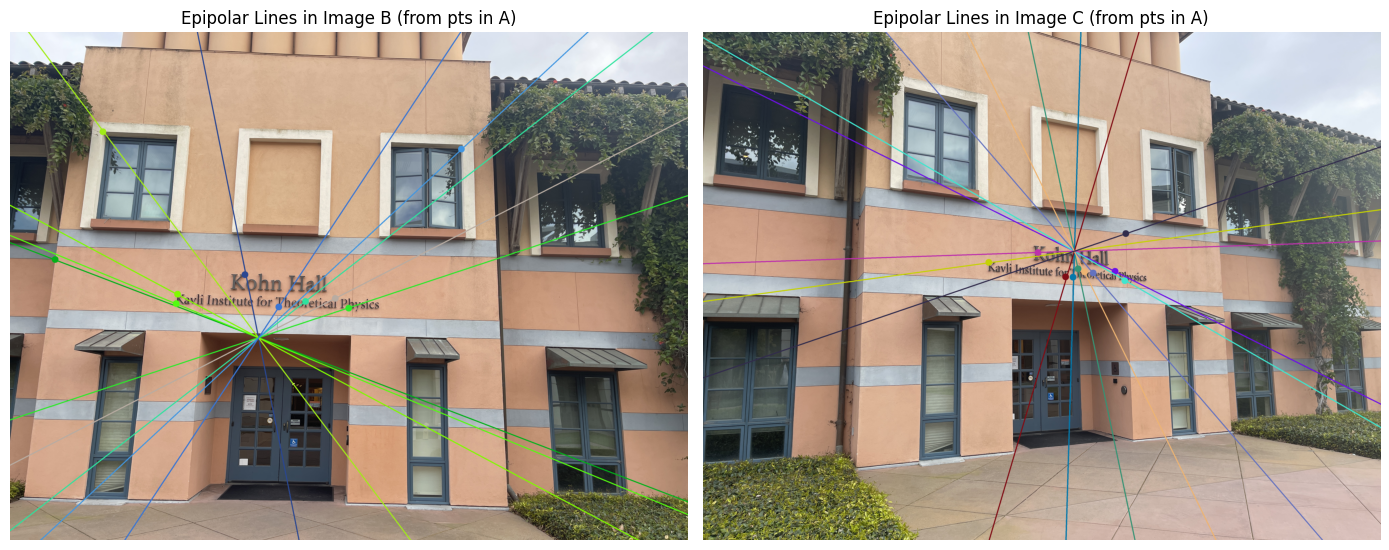

In [7]:
from FundamentalMat import FundamentalMat

FM = FundamentalMat()
F1, inlier1 = FM.compute_fundamental_matrix_ransac(pts_A, pts_B)
F2, inlier2 = FM.compute_fundamental_matrix_ransac(pts_B2, pts_C)
F3, inlier3 = FM.compute_fundamental_matrix_ransac(pts_A2, pts_C2)
pts_A, pts_B = pts_A[inlier1], pts_B[inlier1]
pts_B2, pts_C = pts_B2[inlier2], pts_C[inlier2]
pts_A2, pts_C2 = pts_A2[inlier3], pts_C2[inlier3]
print("Estimated Fundamental Matrix F1:\n", F1)
print("Estimated Fundamental Matrix F2:\n", F2)
print("Estimated Fundamental Matrix F3:\n", F3)
img_A = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1223.jpg')
img_B = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1224.jpg')
img_C = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1226.jpg')
FM.draw_epipolar_lines(img_A, img_B, img_C, pts_A[10:20], pts_B[10:20], pts_A2[10:20], pts_C2[10:20], F1, F3)

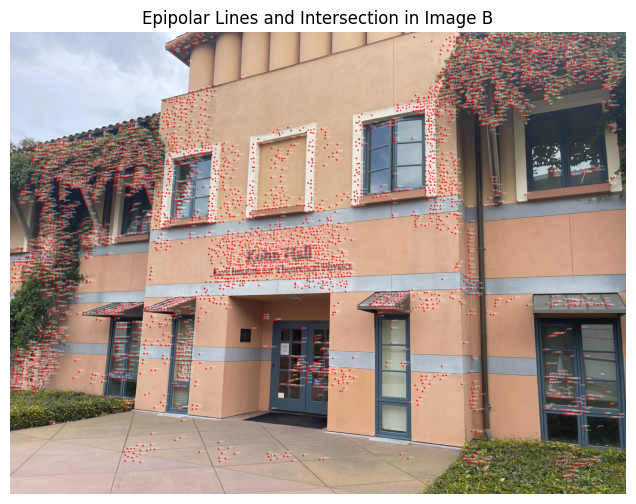

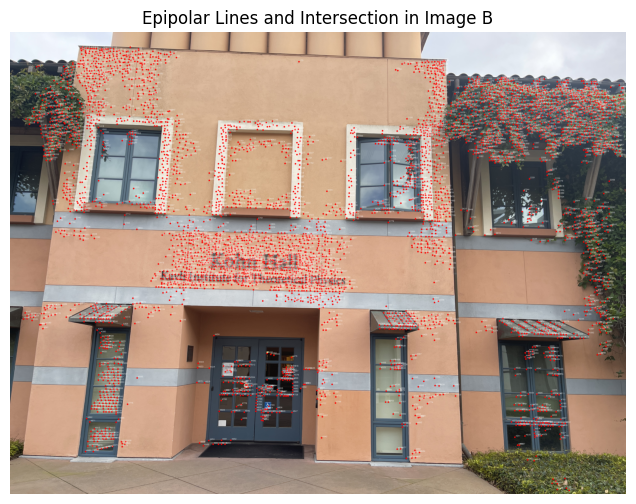

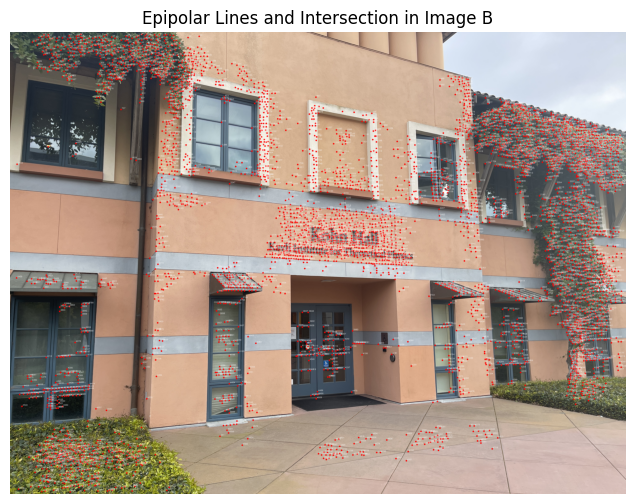

In [8]:
# Disk
# Load keypoints from features.h5
with h5py.File('outputs/disk/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load the actual image
img1 = cv2.imread('G:\Machine Learning\CV\IMG_1223.jpg')
img2 = cv2.imread('G:\Machine Learning\CV\IMG_1224.jpg')
img3 = cv2.imread('G:\Machine Learning\CV\IMG_1226.jpg')

# Draw keypoints
for idx, (x, y) in enumerate(kpts1):
    x, y = int(x), int(y)
    cv2.circle(img1, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img1, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()
# Draw keypoints
for idx, (x, y) in enumerate(kpts2):
    x, y = int(x), int(y)
    cv2.circle(img2, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img2, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()
# Draw keypoints
for idx, (x, y) in enumerate(kpts3):
    x, y = int(x), int(y)
    cv2.circle(img3, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img3, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()

In [9]:
import h5py
import numpy as np
import cv2

img1_name = 'IMG_1223.JPG'
img2_name = 'IMG_1224.JPG'
img3_name = 'IMG_1226.JPG'

# Load keypoints from features.h5
with h5py.File('outputs/disk/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load LightGlue matches0 from matches.h5
with h5py.File('outputs/disk/matches.h5', 'r') as f:
    matches0 = f[img1_name][img2_name]['matches0'][:]  # shape (N1,)
    matches1 = f[img2_name][img3_name]['matches0'][:]  # shape (N1,)
    matches2 = f[img1_name][img3_name]['matches0'][:]  # shape (N1,)

# Valid matches are those >= 0
valid_ab = matches0 > -1
pts_A = kpts1[valid_ab]
pts_B = kpts2[matches0[valid_ab]]

# B-C matching
valid_bc = matches1 > -1
pts_B2 = kpts2[valid_bc]
pts_C = kpts3[matches1[valid_bc]]

# A-C direct matching
valid_ac = matches2 > -1
pts_A2 = kpts1[valid_ac]
pts_C2 = kpts3[matches2[valid_ac]]
pts_A = np.array(pts_A, dtype=np.float32)
pts_B = np.array(pts_B, dtype=np.float32)
pts_C = np.array(pts_C, dtype=np.float32)
pts_A2 = np.array(pts_A2, dtype=np.float32)
pts_B2 = np.array(pts_B2, dtype=np.float32)
pts_C2 = np.array(pts_C2, dtype=np.float32)

from Homography import Homography

# Compute homographies
HMG = Homography()
H1, inlier1 = HMG.compute_homography_ransac(pts_A, pts_B)   # A to B
H2, inlier2 = HMG.compute_homography_ransac(pts_B2, pts_C)  # B to C
H3, inlier3 = HMG.compute_homography_ransac(pts_A2, pts_C2) # A to C
pts_A, pts_B = pts_A[inlier1], pts_B[inlier1]
pts_B2, pts_C = pts_B2[inlier2], pts_C[inlier2]
pts_A2, pts_C2 = pts_A2[inlier3], pts_C2[inlier3]
print("Estimated Homography Matrix 1:\n", H1)
print("Estimated Homography Matrix 2:\n", H2)
print("Estimated Homography Matrix 3:\n", H3)
HA = np.matmul(H1,np.append(pts_A[10],1))
HB = np.matmul(H2,np.append(pts_B2[10],1))
HC = np.matmul(H3,np.append(pts_A2[10],1))
CA = [HA[0]/HA[2],HA[1]/HA[2]]
CB = [HB[0]/HB[2],HB[1]/HB[2]]
CC = [HC[0]/HC[2],HC[1]/HC[2]]
print("Validation A-B: Point in A:",pts_A[10],"Point in B:",pts_B[10],"Reconstructed Point:",CA)
print("Validation B-C: Point in B:",pts_B2[10],"Point in C:",pts_C[10],"Reconstructed Point:",CB)
print("Validation A-C: Point in A:",pts_A2[10],"Point in C:",pts_C2[10],"Reconstructed Point:",CC)

Estimated Homography Matrix 1:
 [[ 2.26976579e+00 -4.42122803e-02 -1.67723032e+03]
 [ 5.40287494e-01  1.57601303e+00 -1.13915595e+03]
 [ 2.49543818e-04 -2.50892193e-05  1.00000000e+00]]
Estimated Homography Matrix 2:
 [[ 1.34991791e+00  1.79981887e-01  4.51066797e+02]
 [ 2.55052843e-01  1.24465119e+00 -5.21728116e+02]
 [ 1.51150868e-04  4.59712551e-05  1.00000000e+00]]
Estimated Homography Matrix 3:
 [[ 4.61217897e+00  3.16665746e-01 -2.82028530e+03]
 [ 1.57041300e+00  2.78492395e+00 -3.31701239e+03]
 [ 8.66250342e-04  6.45856897e-05  1.00000000e+00]]
Validation A-B: Point in A: [2766.    386.25] Point in B: [2728.   575.5] Reconstructed Point: [2727.6020903915364, 573.6310932174955]
Validation B-C: Point in B: [2766.     237.625] Point in C: [2962.  336.] Reconstructed Point: [2958.493048993381, 335.55343728504]
Validation A-C: Point in A: [1432.  855.] Point in C: [1767.   570.5] Reconstructed Point: [1766.3978958983987, 571.9101013970318]


Estimated Fundamental Matrix F1:
 [[-1.57606500e-07 -1.57577981e-06  2.60946448e-03]
 [ 1.89327437e-06 -6.57576248e-09 -3.00023380e-03]
 [-2.67367915e-03  2.17160996e-03  1.00000000e+00]]
Estimated Fundamental Matrix F2:
 [[ 4.23375078e-08  7.13152226e-07 -1.01677968e-03]
 [-6.09811888e-07 -4.14530627e-08  1.04400127e-03]
 [ 6.29572700e-04 -1.52009066e-03  1.00000000e+00]]
Estimated Fundamental Matrix F3:
 [[ 1.90369767e-07  7.93395544e-07 -1.26360855e-03]
 [-8.56426793e-07 -6.74963653e-08  1.42586706e-03]
 [ 5.17344497e-04 -1.48970393e-03  1.00000000e+00]]


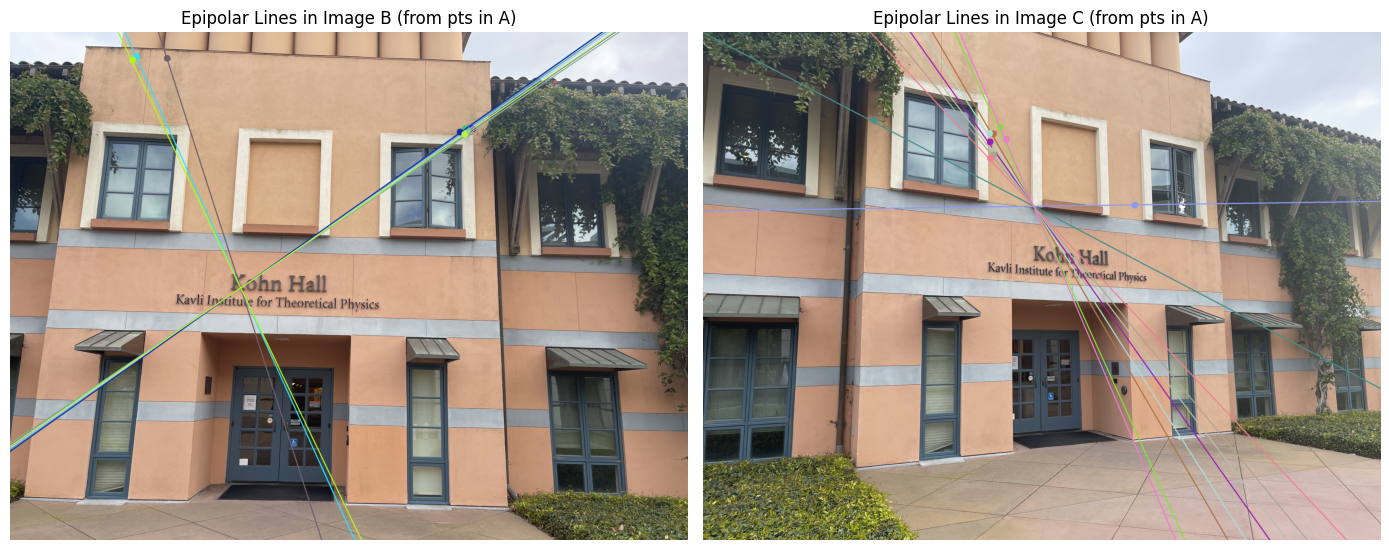

In [10]:
from FundamentalMat import FundamentalMat

FM = FundamentalMat()
F1, inlier1 = FM.compute_fundamental_matrix_ransac(pts_A, pts_B)
F2, inlier2 = FM.compute_fundamental_matrix_ransac(pts_B2, pts_C)
F3, inlier3 = FM.compute_fundamental_matrix_ransac(pts_A2, pts_C2)
pts_A, pts_B = pts_A[inlier1], pts_B[inlier1]
pts_B2, pts_C = pts_B2[inlier2], pts_C[inlier2]
pts_A2, pts_C2 = pts_A2[inlier3], pts_C2[inlier3]
print("Estimated Fundamental Matrix F1:\n", F1)
print("Estimated Fundamental Matrix F2:\n", F2)
print("Estimated Fundamental Matrix F3:\n", F3)
img_A = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1223.jpg')
img_B = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1224.jpg')
img_C = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1226.jpg')
FM.draw_epipolar_lines(img_A, img_B, img_C, pts_A[10:20], pts_B[10:20], pts_A2[10:20], pts_C2[10:20], F1, F3)

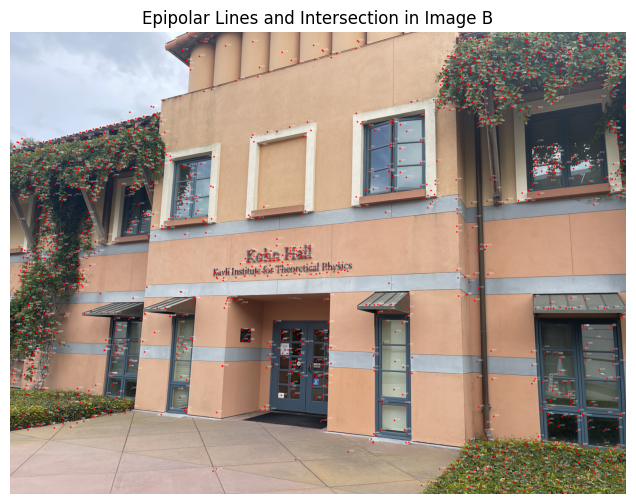

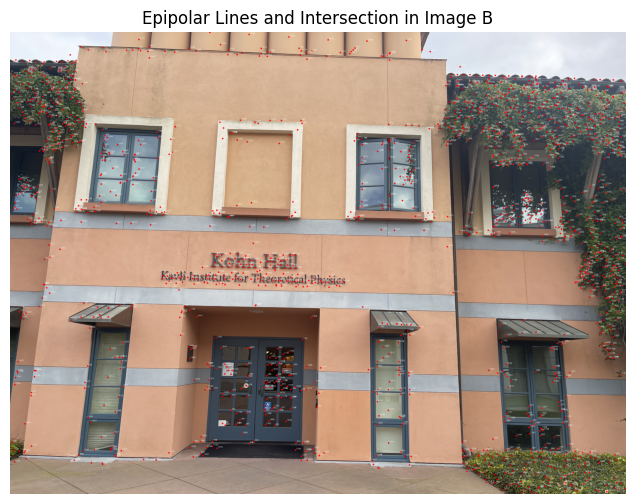

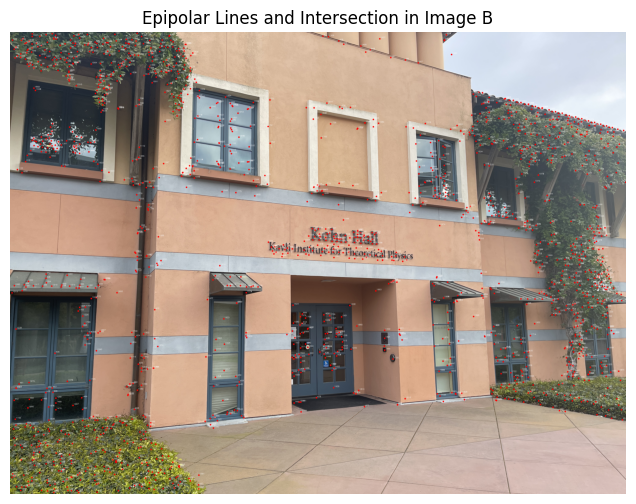

In [11]:
# sift
# Load keypoints from features.h5
with h5py.File('outputs/sift/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load the actual image
img1 = cv2.imread('G:\Machine Learning\CV\IMG_1223.jpg')
img2 = cv2.imread('G:\Machine Learning\CV\IMG_1224.jpg')
img3 = cv2.imread('G:\Machine Learning\CV\IMG_1226.jpg')

# Draw keypoints
for idx, (x, y) in enumerate(kpts1):
    x, y = int(x), int(y)
    cv2.circle(img1, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img1, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()
# Draw keypoints
for idx, (x, y) in enumerate(kpts2):
    x, y = int(x), int(y)
    cv2.circle(img2, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img2, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()
# Draw keypoints
for idx, (x, y) in enumerate(kpts3):
    x, y = int(x), int(y)
    cv2.circle(img3, (x, y), 5, (0, 0, 255), -1)  # Red dot
    cv2.putText(img3, f'{idx}', (x + 5, y - 5),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.4,
                color=(255, 255, 255), thickness=1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
plt.title("Epipolar Lines and Intersection in Image B")
plt.axis('off')
plt.show()

In [12]:
import h5py
import numpy as np
import cv2

img1_name = 'IMG_1223.JPG'
img2_name = 'IMG_1224.JPG'
img3_name = 'IMG_1226.JPG'

# Load keypoints from features.h5
with h5py.File('outputs/sift/features.h5', 'r') as f:
    kpts1 = f[img1_name]['keypoints'][:]
    kpts2 = f[img2_name]['keypoints'][:]
    kpts3 = f[img3_name]['keypoints'][:]

# Load LightGlue matches0 from matches.h5
with h5py.File('outputs/sift/matches.h5', 'r') as f:
    matches0 = f[img1_name][img2_name]['matches0'][:]  # shape (N1,)
    matches1 = f[img2_name][img3_name]['matches0'][:]  # shape (N1,)
    matches2 = f[img1_name][img3_name]['matches0'][:]  # shape (N1,)

# Valid matches are those >= 0
valid_ab = matches0 > -1
pts_A = kpts1[valid_ab]
pts_B = kpts2[matches0[valid_ab]]

# B-C matching
valid_bc = matches1 > -1
pts_B2 = kpts2[valid_bc]
pts_C = kpts3[matches1[valid_bc]]

# A-C direct matching
valid_ac = matches2 > -1
pts_A2 = kpts1[valid_ac]
pts_C2 = kpts3[matches2[valid_ac]]
pts_A = np.array(pts_A, dtype=np.float32)
pts_B = np.array(pts_B, dtype=np.float32)
pts_C = np.array(pts_C, dtype=np.float32)
pts_A2 = np.array(pts_A2, dtype=np.float32)
pts_B2 = np.array(pts_B2, dtype=np.float32)
pts_C2 = np.array(pts_C2, dtype=np.float32)

from Homography import Homography

# Compute homographies
HMG = Homography()
H1, inlier1 = HMG.compute_homography_ransac(pts_A, pts_B)   # A to B
H2, inlier2 = HMG.compute_homography_ransac(pts_B2, pts_C)  # B to C
H3, inlier3 = HMG.compute_homography_ransac(pts_A2, pts_C2) # A to C
pts_A, pts_B = pts_A[inlier1], pts_B[inlier1]
pts_B2, pts_C = pts_B2[inlier2], pts_C[inlier2]
pts_A2, pts_C2 = pts_A2[inlier3], pts_C2[inlier3]
print("Estimated Homography Matrix 1:\n", H1)
print("Estimated Homography Matrix 2:\n", H2)
print("Estimated Homography Matrix 3:\n", H3)
HA = np.matmul(H1,np.append(pts_A[10],1))
HB = np.matmul(H2,np.append(pts_B2[10],1))
HC = np.matmul(H3,np.append(pts_A2[10],1))
CA = [HA[0]/HA[2],HA[1]/HA[2]]
CB = [HB[0]/HB[2],HB[1]/HB[2]]
CC = [HC[0]/HC[2],HC[1]/HC[2]]
print("Validation A-B: Point in A:",pts_A[10],"Point in B:",pts_B[10],"Reconstructed Point:",CA)
print("Validation B-C: Point in B:",pts_B2[10],"Point in C:",pts_C[10],"Reconstructed Point:",CB)
print("Validation A-C: Point in A:",pts_A2[10],"Point in C:",pts_C2[10],"Reconstructed Point:",CC)

Estimated Homography Matrix 1:
 [[ 2.27573688e+00 -4.08369994e-02 -1.67736499e+03]
 [ 5.37739584e-01  1.58231898e+00 -1.13314038e+03]
 [ 2.47666263e-04 -1.70749194e-05  1.00000000e+00]]
Estimated Homography Matrix 2:
 [[ 1.21689228e+00  1.84258628e-01  5.24000087e+02]
 [ 1.91174259e-01  1.21525793e+00 -4.55226082e+02]
 [ 1.08050081e-04  5.30786564e-05  1.00000000e+00]]
Estimated Homography Matrix 3:
 [[ 4.57281513e+00  2.27021285e-01 -2.68117885e+03]
 [ 1.55422471e+00  2.74705707e+00 -3.27381051e+03]
 [ 8.55528432e-04  5.72071329e-05  1.00000000e+00]]
Validation A-B: Point in A: [1340. 1575.] Point in B: [1003. 1595.] Reconstructed Point: [1002.1642956947779, 1593.5749126961052]
Validation B-C: Point in B: [1336. 1456.] Point in C: [1980. 1287.] Reconstructed Point: [1979.350563974564, 1284.8315136706963]
Validation A-C: Point in A: [1394. 1626.] Point in C: [1780. 1470.] Reconstructed Point: [1777.3962387226325, 1469.8355637752434]


Estimated Fundamental Matrix F1:
 [[-1.37252809e-07 -1.38688039e-06  2.33939355e-03]
 [ 1.58887166e-06  1.71752205e-07 -3.04579452e-03]
 [-2.26822462e-03  1.96727978e-03  1.00000000e+00]]
Estimated Fundamental Matrix F2:
 [[ 4.77208114e-08  9.02343829e-07 -1.50182141e-03]
 [-7.80550322e-07 -2.56641855e-07  1.64355868e-03]
 [ 9.95189387e-04 -1.63137439e-03  1.00000000e+00]]
Estimated Fundamental Matrix F3:
 [[ 9.10780923e-08  6.73533852e-07 -1.16730308e-03]
 [-6.52644964e-07 -9.63986091e-09  1.24520391e-03]
 [ 6.87614412e-04 -1.55400906e-03  1.00000000e+00]]


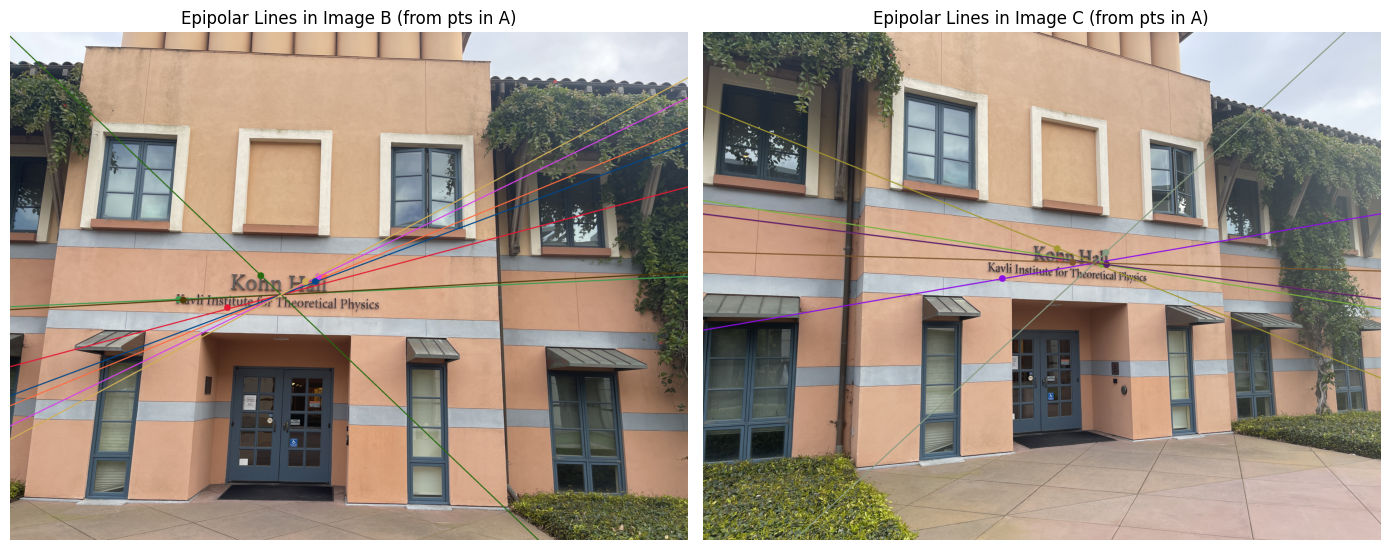

In [13]:
from FundamentalMat import FundamentalMat

FM = FundamentalMat()
F1, inlier1 = FM.compute_fundamental_matrix_ransac(pts_A, pts_B)
F2, inlier2 = FM.compute_fundamental_matrix_ransac(pts_B2, pts_C)
F3, inlier3 = FM.compute_fundamental_matrix_ransac(pts_A2, pts_C2)
pts_A, pts_B = pts_A[inlier1], pts_B[inlier1]
pts_B2, pts_C = pts_B2[inlier2], pts_C[inlier2]
pts_A2, pts_C2 = pts_A2[inlier3], pts_C2[inlier3]
print("Estimated Fundamental Matrix F1:\n", F1)
print("Estimated Fundamental Matrix F2:\n", F2)
print("Estimated Fundamental Matrix F3:\n", F3)
img_A = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1223.jpg')
img_B = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1224.jpg')
img_C = cv2.imread('G:\Machine Learning\Hierarchical-Localization\datasets\A\IMG_1226.jpg')
FM.draw_epipolar_lines(img_A, img_B, img_C, pts_A[10:20], pts_B[10:20], pts_A2[10:20], pts_C2[10:20], F1, F3)